# 02 — Exploratory Data Analysis

Working on the cleaned tables (`*_clean`), we look for the patterns that will
drive the SQL analysis and the dashboard:

- Order volume distribution across vendors
- Monthly on-time delivery trend
- Defect-rate distribution (inspected POs only)
- Delivery-delay histogram
- Price variance by category
- Inspection coverage per vendor

All charts use Matplotlib only (no seaborn) per project constraints.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

CLEAN = Path.cwd().parent / "data" / "clean"
FIG   = Path.cwd().parent / "report" / "figures"

po = pd.read_csv(CLEAN / "purchase_orders_clean.csv",
                 parse_dates=["order_date", "promised_date", "actual_delivery_date"])
v  = pd.read_csv(CLEAN / "vendors_clean.csv")
qi = pd.read_csv(CLEAN / "quality_inspections_clean.csv")
po.shape, v.shape, qi.shape


((1400, 12), (20, 6), (840, 7))

## Order volume by vendor

Uneven volume — a handful of heavy suppliers and a long tail of light ones.
This is why the composite score has a ≥ 20 PO eligibility rule: small-sample
vendors give noisy KPIs.


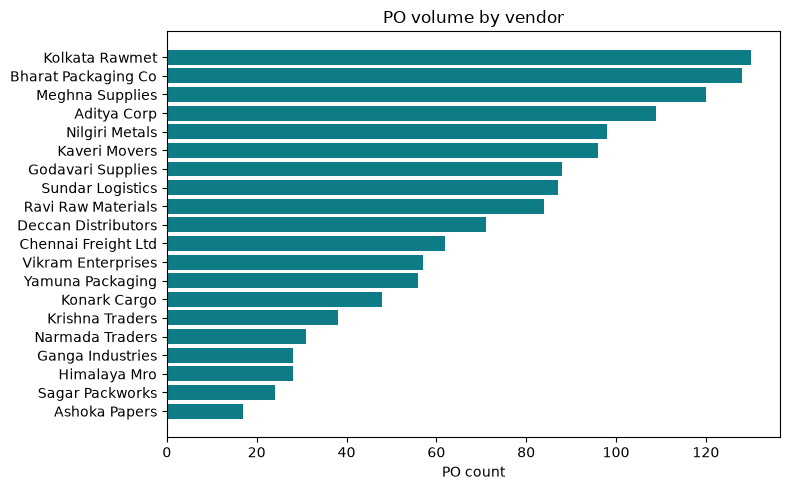

In [2]:
vol = po.groupby("vendor_id").size().reset_index(name="pos").merge(
        v[["vendor_id", "vendor_name"]], on="vendor_id"
      ).sort_values("pos")

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(vol["vendor_name"], vol["pos"], color="#0E7C86")
ax.set_title("PO volume by vendor"); ax.set_xlabel("PO count")
plt.tight_layout(); plt.show()


## Monthly on-time delivery — average and one declining vendor

The average line is roughly flat; but V005 (Sundar Logistics) drops after
month 4 — a directional issue that an annual average would hide.


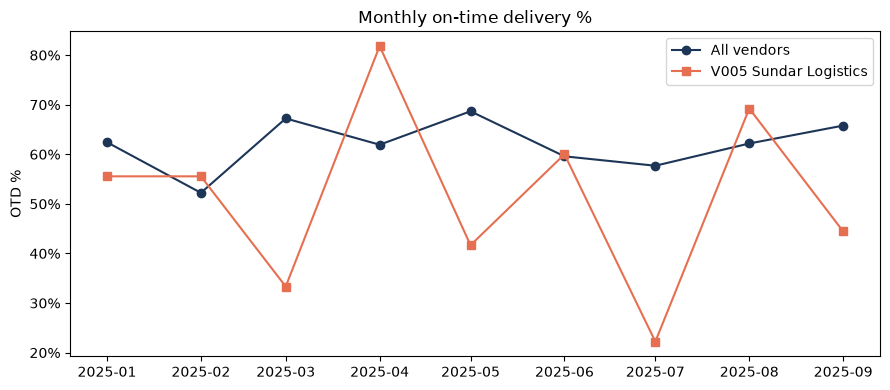

In [3]:
po['is_late']     = po['actual_delivery_date'] > po['promised_date']
po['delivered']   = po['actual_delivery_date'].notna()
po['month']       = po['order_date'].dt.to_period('M').dt.to_timestamp()

def otd(group):
    d = group['delivered'].sum()
    if d == 0: return None
    return 100 * (group['delivered'].sum() - group['is_late'].sum()) / d

monthly_all = po.groupby('month').apply(otd).reset_index(name='otd_pct')
v005 = po[po['vendor_id'] == 'V005'].groupby('month').apply(otd).reset_index(name='otd_pct')

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(monthly_all['month'], monthly_all['otd_pct'], marker='o', color='#1D3557', label='All vendors')
ax.plot(v005['month'], v005['otd_pct'], marker='s', color='#E76F51', label='V005 Sundar Logistics')
ax.set_title('Monthly on-time delivery %'); ax.set_ylabel('OTD %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(); plt.tight_layout(); plt.show()


## Defect distribution (inspected POs only)

Long right tail. Most inspections show < 5 % defect rate; a handful spike
above 10 %. Note this is over inspected POs — non-inspected POs are excluded.


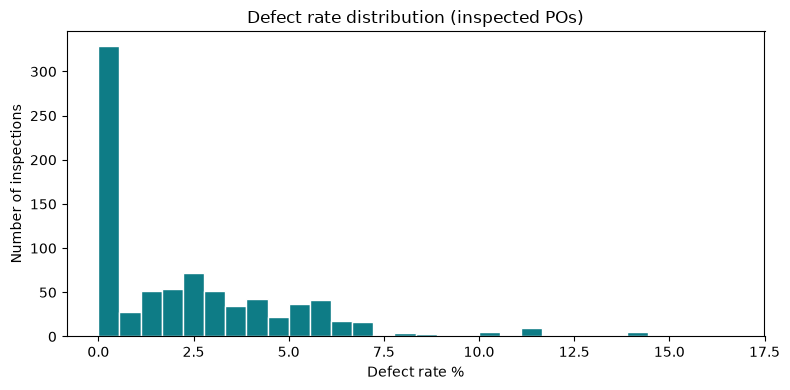

In [4]:
qi_ok = qi.dropna(subset=['defect_count'])
dr = 100 * qi_ok['defect_count'] / qi_ok['inspected_quantity']

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(dr, bins=30, color='#0E7C86', edgecolor='white')
ax.set_title('Defect rate distribution (inspected POs)')
ax.set_xlabel('Defect rate %'); ax.set_ylabel('Number of inspections')
plt.tight_layout(); plt.show()


## Delivery-delay histogram

Delay in days after the promised date. Centre is near zero with a long right
tail — when a vendor misses, they tend to miss badly.


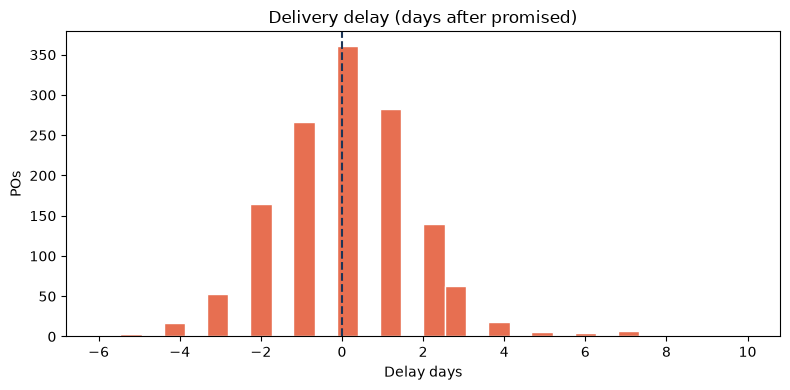

In [5]:
delivered = po.dropna(subset=['actual_delivery_date']).copy()
delivered['delay'] = (delivered['actual_delivery_date'] - delivered['promised_date']).dt.days

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(delivered['delay'], bins=30, color='#E76F51', edgecolor='white')
ax.axvline(0, color='#1D3557', linestyle='--')
ax.set_title('Delivery delay (days after promised)')
ax.set_xlabel('Delay days'); ax.set_ylabel('POs')
plt.tight_layout(); plt.show()


## Price variance by category


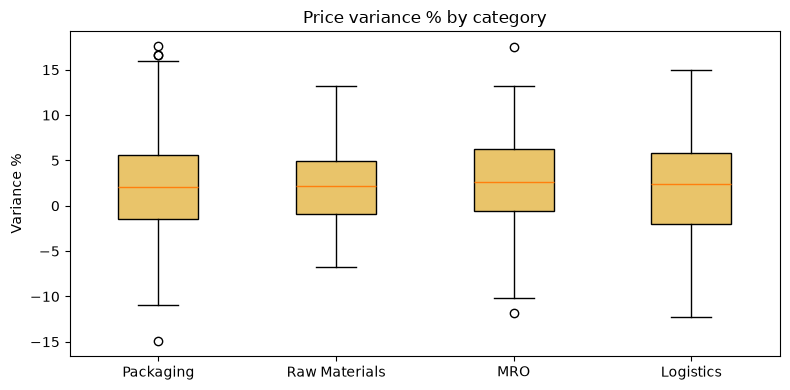

In [6]:
m = po.merge(v[['vendor_id', 'vendor_category']], on='vendor_id')
m = m[m['agreed_price'] > 0].copy()
m['var_pct'] = 100 * (m['unit_price'] - m['agreed_price']) / m['agreed_price']
cats = m['vendor_category'].unique()
data = [m.loc[m['vendor_category'] == c, 'var_pct'].values for c in cats]

fig, ax = plt.subplots(figsize=(8,4))
bp = ax.boxplot(data, tick_labels=cats, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#E9C46A')
ax.set_title('Price variance % by category'); ax.set_ylabel('Variance %')
plt.tight_layout(); plt.show()


## Inspection coverage per vendor

Vendors with low inspection coverage have less reliable quality scores.
This is a documented limitation of the composite score.


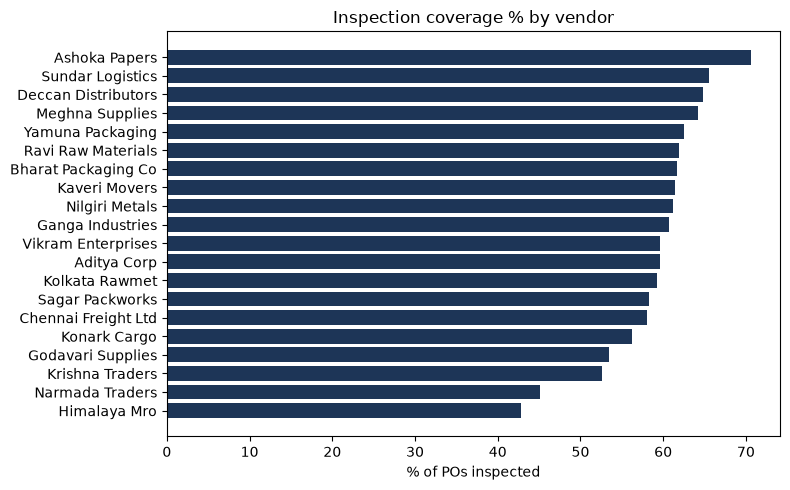

In [7]:
cov = po.groupby('vendor_id').size().reset_index(name='total_pos')
insp = qi.merge(po[['po_number','vendor_id']], on='po_number').groupby('vendor_id').size().reset_index(name='inspected')
cov = cov.merge(insp, on='vendor_id', how='left').fillna(0)
cov['pct'] = 100 * cov['inspected'] / cov['total_pos']
cov = cov.merge(v[['vendor_id','vendor_name']], on='vendor_id').sort_values('pct')

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(cov['vendor_name'], cov['pct'], color='#1D3557')
ax.set_title('Inspection coverage % by vendor'); ax.set_xlabel('% of POs inspected')
plt.tight_layout(); plt.show()


## Takeaways for the SQL layer

- Use LEFT JOIN on `quality_inspections_clean` so non-inspected POs stay in
  vendor totals but only inspected rows drive the defect-rate calculation.
- Exclude missing-actual-date rows from the OTD denominator.
- Compare pre-M4 and post-M4 windows to catch quality regressions the
  average would hide (V005).
- Require ≥ 20 POs for eligibility on the composite score.
